In [134]:
import pandas as pd

movies = pd.read_csv('ml-latest-small/movies.csv')
ratings = pd.read_csv('ml-latest-small/ratings.csv')
tags = pd.read_csv('ml-latest-small/tags.csv')
links = pd.read_csv('ml-latest-small/links.csv')

print(movies.head())
print(ratings.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [135]:
print(movies.isnull().sum())
print(ratings.isnull().sum())
print(tags.isnull().sum())
print(links.isnull().sum())

movieId    0
title      0
genres     0
dtype: int64
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
userId       0
movieId      0
tag          0
timestamp    0
dtype: int64
movieId    0
imdbId     0
tmdbId     8
dtype: int64


In [136]:
print(movies.duplicated().sum())
print(ratings.duplicated().sum())
print(tags.duplicated().sum())

0
0
0


In [137]:
movies['genres'] = movies['genres'].str.replace('|', ' ')

In [138]:
movies['title'] = movies['title'].str.strip()

In [139]:
ratings['userId'] = ratings['userId'].astype(int)
ratings['movieId'] = ratings['movieId'].astype(int)
ratings['rating'] = ratings['rating'].astype(float)

In [140]:
movies

,movieId,title,genres
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy
1,2,Jumanji (1995),Adventure Children Fantasy
2,3,Grumpier Old Men (1995),Comedy Romance
3,4,Waiting to Exhale (1995),Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action Animation Comedy Fantasy
9738,193583,No Game No Life: Zero (2017),Animation Comedy Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action Animation


In [141]:
movies = movies[movies['genres'] != '(no genres listed)']

movies

,movieId,title,genres
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy
1,2,Jumanji (1995),Adventure Children Fantasy
2,3,Grumpier Old Men (1995),Comedy Romance
3,4,Waiting to Exhale (1995),Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action Animation Comedy Fantasy
9738,193583,No Game No Life: Zero (2017),Animation Comedy Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action Animation


In [142]:
tags_grouped = tags.groupby('movieId')['tag'].apply(
    lambda x: ' '.join(x.astype(str))
)

movies = movies.merge(
    tags_grouped,
    on='movieId',
    how='left'
)

movies['tag'] = movies['tag'].fillna('')

tags_grouped

movieId
1                                         pixar pixar fun
2            fantasy magic board game Robin Williams game
3                                               moldy old
5                                        pregnancy remake
7                                                  remake
                               ...                       
183611                        Comedy funny Rachel McAdams
184471    adventure Alicia Vikander video game adaptation
187593                  Josh Brolin Ryan Reynolds sarcasm
187595                            Emilia Clarke star wars
193565                      anime comedy gintama remaster
Name: tag, Length: 1572, dtype: str

In [143]:
movies['metadata'] = (
    movies['genres'] + ' ' + movies['tag']
)

In [144]:
movie_data = pd.merge(
    ratings,
    movies,
    on='movieId'
)

In [145]:
print("Movies:", movies.shape)
print("Ratings:", ratings.shape)
print("Tags:", tags.shape)
print("Links:", links.shape)
print("Merged Movie Data:", movie_data.shape)

Movies: (9708, 5)
Ratings: (100836, 4)
Tags: (3683, 4)
Links: (9742, 3)
Merged Movie Data: (100789, 8)


TF-IDF(t,d)=TF(t,d)×log(N/DF(t))

In [146]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(movies['genres'])

print(tfidf_matrix.shape)

(9708, 21)


In [147]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(
    tfidf_matrix,
    tfidf_matrix
)

print("\nCosine Similarity Shape")
print(cosine_sim.shape)

# Example similarity scores
print("\nSample Similarity Scores")
print(cosine_sim[0][:10])


Cosine Similarity Shape
(9708, 9708)

Sample Similarity Scores
[1.         0.8136036  0.15259961 0.13500041 0.26738778 0.
 0.15259961 0.65470981 0.         0.26241348]


In [148]:
indices = pd.Series(
    movies.index,
    index=movies['title']
)

indices = indices[
    ~indices.index.duplicated(keep='first')
]

indices.head()

title
Toy Story (1995)                      0
Jumanji (1995)                        1
Grumpier Old Men (1995)               2
Waiting to Exhale (1995)              3
Father of the Bride Part II (1995)    4
dtype: int64

In [149]:
indices.shape[0]

9703

In [150]:
def content_recommendations(title, top_n=10):

    idx = indices[title]

    sim_scores = list(
        enumerate(cosine_sim[idx])
    )

    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )

    sim_scores = sim_scores[1:top_n + 1]

    movie_indices = [
        i[0] for i in sim_scores
    ]

    recommendations = movies[
        ['title', 'genres']
    ].iloc[movie_indices]

    return recommendations


In [151]:
content_recommendations('Vampire in Brooklyn (1995)')

,title,genres
5507,Love at First Bite (1979),Comedy Horror Romance
5998,Frankenstein 90 (1984),Comedy Horror Romance
8035,Vamps (2012),Comedy Horror Romance
8058,Warm Bodies (2013),Comedy Horror Romance
8480,Life After Beth (2014),Comedy Horror Romance
1983,"Mummy, The (1932)",Horror Romance
4503,Dracula (1979),Horror Romance
4542,Squirm (1976),Horror Romance
2099,"American Werewolf in Paris, An (1997)",Comedy Horror Romance Thriller
9177,Pride and Prejudice and Zombies (2016),Comedy Horror Romance Thriller


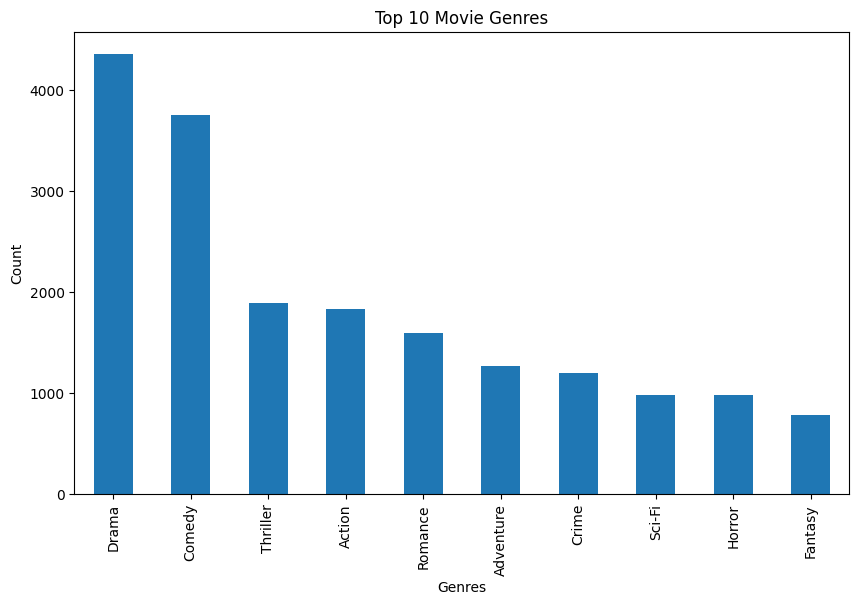

In [152]:
import matplotlib.pyplot as plt

genre_counts = movies['genres'].str.split(
    expand=True
).stack().value_counts()

plt.figure(figsize=(10,6))

genre_counts.head(10).plot(
    kind='bar'
)

plt.title("Top 10 Movie Genres")
plt.xlabel("Genres")
plt.ylabel("Count")

plt.show()

Collaborative Filtering

In [153]:
from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise.model_selection import train_test_split

In [154]:
from surprise import accuracy
# Reader
reader = Reader(
    rating_scale=(0.5, 5)
)

# Dataset
data = Dataset.load_from_df(
    ratings[
        ['userId', 'movieId', 'rating']
    ],
    reader
)

trainset, testset = train_test_split(data, test_size=0.2, random_state=42
)

# SVD Model
svd_model = SVD(n_factors=100, random_state=42 ) #latent factors = 100

# Train Model
svd_model.fit(trainset)

predictions = svd_model.test(testset)
accuracy.rmse(predictions)
accuracy.mae(predictions)



RMSE: 0.8807
MAE:  0.6766


0.6765729095860605

In [155]:
# Full Trainset
full_trainset = data.build_full_trainset()

# Train Final Model
svd_model.fit(full_trainset)

print("Final Model Trained Successfully")

Final Model Trained Successfully


In [156]:
def collaborative_recommendations(
    user_id,
    top_n=10
):

    # Movies watched by user
    watched_movies = ratings[
        ratings['userId'] == user_id
    ]['movieId'].tolist()

    # All movie IDs
    all_movies = movies['movieId'].unique()

    # Movies not watched
    unwatched_movies = [
        movie
        for movie in all_movies
        if movie not in watched_movies
    ]

    # Store predictions
    predictions = []

    # Predict ratings
    for movie_id in unwatched_movies:

        predicted_rating = svd_model.predict(
            user_id,
            movie_id
        ).est

        predictions.append(
            (movie_id, predicted_rating)
        )

    # Sort predictions
    predictions = sorted(
        predictions,
        key=lambda x: x[1],
        reverse=True
    )

    # Top movie IDs
    recommended_movie_ids = [
        movie[0]
        for movie in predictions[:top_n]
    ]

    # Recommended movies
    recommendations = movies[
        movies['movieId'].isin(
            recommended_movie_ids
        )
    ][[
        'title',
        'genres'
    ]]

    return recommendations

In [157]:
print("\nCollaborative Filtering Recommendations")

print(
    collaborative_recommendations(
        user_id=1999
    )
)


Collaborative Filtering Recommendations
                                                  title  \
277                    Shawshank Redemption, The (1994)   
602   Dr. Strangelove or: How I Learned to Stop Worr...   
659                               Godfather, The (1972)   
686                                  Rear Window (1954)   
906                           Lawrence of Arabia (1962)   
914                                   Goodfellas (1990)   
975                               Cool Hand Luke (1967)   
2226                                  Fight Club (1999)   
2462                        Boondock Saints, The (2000)   
2582                Guess Who's Coming to Dinner (1967)   

                           genres  
277                   Crime Drama  
602                    Comedy War  
659                   Crime Drama  
686              Mystery Thriller  
906           Adventure Drama War  
914                   Crime Drama  
975                         Drama  
2226  Action Crime Dr

Hybrid Recommendation System

In [158]:


def hybrid_recommendations(
    user_id,
    title,
    top_n=10,
    alpha=0.5
):

    # Get movie index
    idx = indices[title]

    # Dynamic Cosine Similarity

    sim_scores = cosine_similarity(
        tfidf_matrix[idx],
        tfidf_matrix
    ).flatten() # Flatten to 1D array

    # Enumerate similarity scores
    sim_scores = list(
        enumerate(sim_scores)
    ) # enumerate to get (index, score) pairs

    # Sort by similarity
    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove selected movie itself
    sim_scores = sim_scores[1:50]

    # Get movie indices
    movie_indices = [
        i[0] for i in sim_scores
    ]

    # Candidate movies
    candidate_movies = movies.iloc[
        movie_indices
    ][[
        'movieId',
        'title',
        'genres'
    ]]

    # Store hybrid scores
    hybrid_scores = []

    # Calculate Hybrid Scores

    for movie_index, row in zip( 
        movie_indices,
        candidate_movies.iterrows() #iterrows to get (index, row) pairs
    ):

        row = row[1]

        movie_id = row['movieId']

        # Content-Based Score

        content_score = cosine_similarity(
            tfidf_matrix[idx],
            tfidf_matrix[movie_index]
        )[0][0]

        # Collaborative Score

        try:

            collaborative_score = svd_model.predict(
                user_id,
                movie_id
            ).est # Estimated rating

            # Normalize
            collaborative_score = (
                collaborative_score / 5 # Normalize to [0,1]
            )

        except:

            collaborative_score = 0

        # Hybrid Score

        hybrid_score = ( alpha * content_score + (1 - alpha)* collaborative_score )

        # Append score
        hybrid_scores.append(
            hybrid_score
        )

    # Add Scores

    candidate_movies[
        'hybrid_score'
    ] = hybrid_scores

    # Sort Recommendations

    recommendations = candidate_movies.sort_values(
        by='hybrid_score',
        ascending=False
    )

    return recommendations.head(top_n)

HybridScore=α(ContentScore)+(1−α)(CollaborativeScore)

In [159]:
print(
    hybrid_recommendations(
        user_id=654,
        title='Toy Story (1995)'
    )
)

      movieId                                              title  \
3568     4886                              Monsters, Inc. (2001)   
2355     3114                                 Toy Story 2 (1999)   
3000     4016                   Emperor's New Groove, The (2000)   
6944    65261                 Ponyo (Gake no ue no Ponyo) (2008)   
8895   134853                                  Inside Out (2015)   
7760    91355  Asterix and the Vikings (Astérix et les Viking...   
3194     4306                                       Shrek (2001)   
9410   166461                                       Moana (2016)   
5546    26662  Kiki's Delivery Service (Majo no takkyûbin) (1...   
8357   108932                              The Lego Movie (2014)   

                                                 genres  hybrid_score  
3568        Adventure Animation Children Comedy Fantasy      0.891145  
2355        Adventure Animation Children Comedy Fantasy      0.890484  
3000        Adventure Animation Chi

In [160]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    precision_score,
    recall_score,
    f1_score
)

from math import sqrt

In [161]:
actual_ratings = []
predicted_values = []

# Loop through ratings dataset
for row in ratings.itertuples(): 

    user_id = row.userId
    movie_id = row.movieId
    actual_rating = row.rating

    # Predict rating using Surprise SVD
    predicted_rating = svd_model.predict(
        user_id,
        movie_id
    ).est

    # Store actual rating
    actual_ratings.append(
        actual_rating
    )

    # Store predicted rating
    predicted_values.append(
        predicted_rating
    )

#print first 5

print("Actual Ratings:", actual_ratings[:5])
print("Predicted Ratings:", predicted_values[:5])

Actual Ratings: [4.0, 4.0, 4.0, 5.0, 5.0]
Predicted Ratings: [4.796607273569183, 4.096429413422194, 4.562520088560928, 4.600203166664923, 5]


RMSE = √(1/n * Σ(y - ŷ)²)

In [162]:
rmse = sqrt(
    mean_squared_error(
        actual_ratings,
        predicted_values
    )
)

print("\nRMSE")
print(rmse)


RMSE
0.6389944740643381


MAE = 1/n * Σ|y - ŷ|

In [163]:
mae = mean_absolute_error(
    actual_ratings,
    predicted_values
)

print("\nMAE")
print(mae)


MAE
0.4958861197295551


In [164]:
actual_binary = [
    1 if rating >= 3.5 else 0
    for rating in actual_ratings
]

predicted_binary = [
    1 if rating >= 3.5 else 0
    for rating in predicted_values
]


In [165]:

precision = precision_score(
    actual_binary,
    predicted_binary
)

print("\nPrecision")
print(precision)


recall = recall_score(
    actual_binary,
    predicted_binary
)

print("\nRecall")
print(recall)



f1 = f1_score(
    actual_binary,
    predicted_binary
)

print("\nF1 Score")
print(f1)


Precision
0.8883180581412

Recall
0.8040864605612807

F1 Score
0.844106140500085


In [166]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    actual_binary, predicted_binary
)
accuracy

0.8182196834463882